# PHÂN TÍCH LỰC KIỂM ĐỊNH (POWER ANALYSIS)

Phân tích lực lượng thống kê (Statistical power analysis) là phương pháp được sử dụng để xác định cỡ mẫu tối thiểu cần thiết để phát hiện một kích thước hiệu ứng (effect size) nhất định với mức độ tin cậy mong muốn.

Notebook này bao gồm:

* Tính toán kích thước hiệu ứng (Cohen's d)
* Ước lượng cỡ mẫu yêu cầu (Required Sample Size)
* Trực quan hóa đường cong lực kiểm định (Power Curve)
* Diễn giải kết quả phân tích

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import TTestIndPower

In [2]:
df = pd.read_csv('../data/processed/cleaned_marketing.csv')
df['date'] = pd.to_datetime(df['date'])

In [3]:
control = df[df['group'] == 'control'].dropna(subset=['purchase'])
test = df[df['group'] == 'test'].dropna(subset=['purchase'])

print('Control group size:', len(control))
print('Test group size:', len(test))

Control group size: 29
Test group size: 30


## 1. Kích thước hiệu ứng - Effect Size (Cohen's d)

Cohen's d đo lường sự khác biệt chuẩn hóa giữa hai giá trị trung bình.
- Hiệu ứng nhỏ: d = 0.2
- Hiệu ứng trung bình: d = 0.5
- Hiệu ứng lớn: d = 0.8

In [4]:
mean_control = control['purchase'].mean()
mean_test = test['purchase'].mean()
std_control = control['purchase'].std()
std_test = test['purchase'].std()
n_control = len(control)
n_test = len(test)

# Pooled standard deviation
pooled_std = np.sqrt(
    ((n_control - 1) * std_control**2 + (n_test - 1) * std_test**2)
    / (n_control + n_test - 2)
)

cohens_d = (mean_control - mean_test) / pooled_std

print(f'Mean Purchase (Control): {mean_control:.2f}')
print(f'Mean Purchase (Test):    {mean_test:.2f}')
print(f'Pooled Std Dev:          {pooled_std:.2f}')
print(f"Cohen's d:               {cohens_d:.4f}")
print(f"Effect size magnitude:   {'Small' if abs(cohens_d) < 0.5 else 'Medium' if abs(cohens_d) < 0.8 else 'Large'}")

Mean Purchase (Control): 522.79
Mean Purchase (Test):    521.23
Pooled Std Dev:          198.69
Cohen's d:               0.0079
Effect size magnitude:   Small


## 2. Cỡ mẫu yêu cầu (Required Sample Size)

Với các tham số:
- Mức ý nghĩa (alpha) = 0.05
- Lực lượng kiểm định mong muốn (1 - beta) = 0.80
- Kích thước hiệu ứng = chỉ số Cohen's d tính toán ở trên

In [5]:
power_analysis = TTestIndPower()

alpha = 0.05
power = 0.80

# Use absolute value of Cohen's d
effect_size = abs(cohens_d)

# Calculate required sample size per group
required_n = power_analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    alternative='two-sided'
)

print(f'Required sample size per group: {required_n:.0f}')
print(f'Current control group size: {n_control}')
print(f'Current test group size:    {n_test}')
print()
if n_control >= required_n and n_test >= required_n:
    print('✓ Current sample sizes are sufficient.')
else:
    print('✗ Current sample sizes are INSUFFICIENT for desired power.')

Required sample size per group: 254730
Current control group size: 29
Current test group size:    30

✗ Current sample sizes are INSUFFICIENT for desired power.


## 3. Lực lượng kiểm định đạt được thực tế (Achieved Power)

Với cỡ mẫu hiện tại, lực lượng kiểm định thực tế (statistical power) của phép thử là bao nhiêu?

In [6]:
achieved_power = power_analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    nobs1=n_control,
    alternative='two-sided'
)

print(f'Achieved Statistical Power: {achieved_power:.4f} ({achieved_power*100:.2f}%)')
print(f'Type II Error (Beta):       {1 - achieved_power:.4f} ({(1-achieved_power)*100:.2f}%)')

Achieved Statistical Power: 0.0501 (5.01%)
Type II Error (Beta):       0.9499 (94.99%)


## 4. Đường cong lực lượng kiểm định (Power Curve)

Trực quan hóa cách lực lượng kiểm định thay đổi khi cỡ mẫu tăng lên đối với các kích thước hiệu ứng khác nhau.

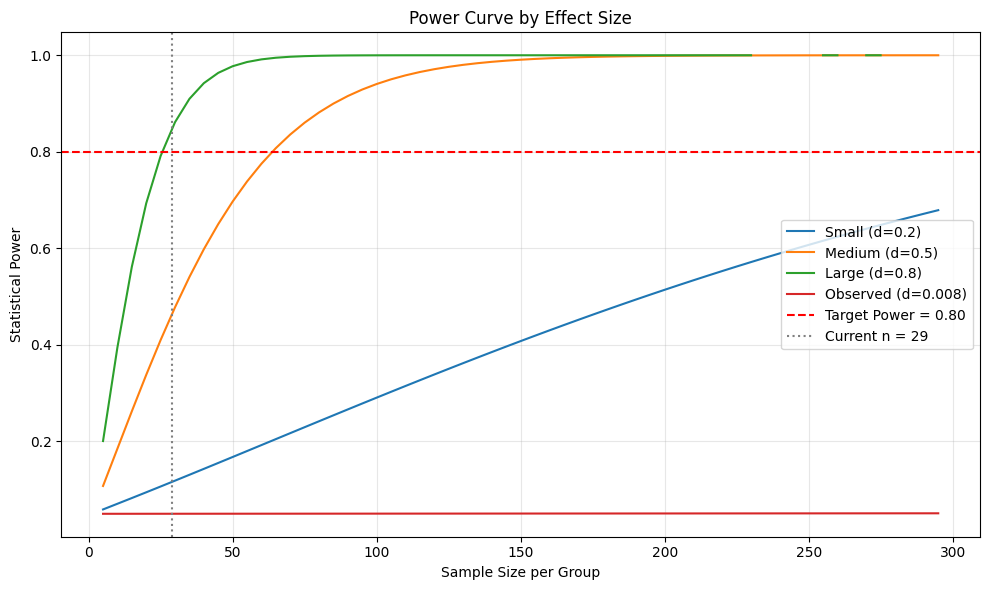

In [7]:
sample_sizes = np.arange(5, 300, 5)
effect_sizes = [0.2, 0.5, 0.8, abs(cohens_d)]
labels = ['Small (d=0.2)', 'Medium (d=0.5)', 'Large (d=0.8)', f'Observed (d={abs(cohens_d):.3f})']

plt.figure(figsize=(10, 6))

for es, label in zip(effect_sizes, labels):
    powers = [
        power_analysis.solve_power(
            effect_size=es,
            alpha=0.05,
            nobs1=n,
            alternative='two-sided'
        )
        for n in sample_sizes
    ]
    plt.plot(sample_sizes, powers, label=label)

plt.axhline(y=0.80, color='red', linestyle='--', label='Target Power = 0.80')
plt.axvline(x=n_control, color='gray', linestyle=':', label=f'Current n = {n_control}')

plt.xlabel('Sample Size per Group')
plt.ylabel('Statistical Power')
plt.title('Power Curve by Effect Size')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Cỡ mẫu so với Mức ý nghĩa Alpha (Sample Size vs Alpha)

Ngưỡng ý nghĩa (alpha) ảnh hưởng như thế nào đến cỡ mẫu yêu cầu?

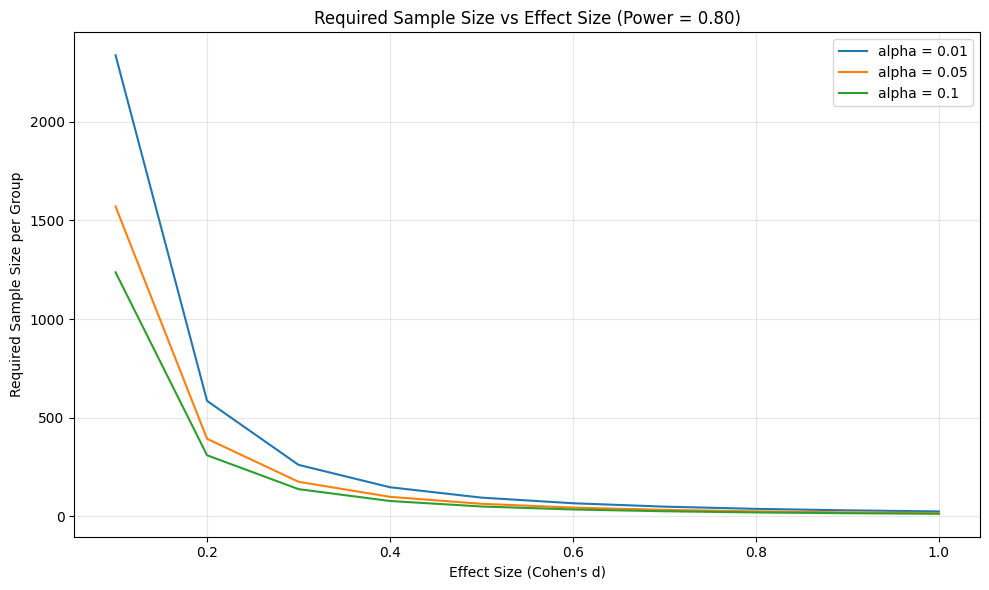

In [8]:
alphas = [0.01, 0.05, 0.10]
effect_size_vals = np.arange(0.1, 1.1, 0.1)

plt.figure(figsize=(10, 6))

for a in alphas:
    required_sizes = [
        power_analysis.solve_power(
            effect_size=es,
            alpha=a,
            power=0.80,
            alternative='two-sided'
        )
        for es in effect_size_vals
    ]
    plt.plot(effect_size_vals, required_sizes, label=f'alpha = {a}')

plt.xlabel("Effect Size (Cohen's d)")
plt.ylabel('Required Sample Size per Group')
plt.title('Required Sample Size vs Effect Size (Power = 0.80)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Bảng tổng hợp (Summary Table)

In [9]:
summary = []
for a in [0.01, 0.05, 0.10]:
    for p in [0.70, 0.80, 0.90]:
        n = power_analysis.solve_power(
            effect_size=effect_size,
            alpha=a,
            power=p,
            alternative='two-sided'
        )
        summary.append({
            'Alpha': a,
            'Power': p,
            'Required N per group': int(np.ceil(n))
        })

summary_df = pd.DataFrame(summary)
print(f"Effect Size (Cohen's d) = {effect_size:.4f}")
print()
print(summary_df.to_string(index=False))
print()

# In rõ kết luận về cỡ mẫu hiện tại
required_n_standard = summary_df[(summary_df['Alpha'] == 0.05) & (summary_df['Power'] == 0.80)]['Required N per group'].values[0]
print("=== KẾT LUẬN CỠ MẪU CURRENT SAMPLE ===")
if n_control >= required_n_standard and n_test >= required_n_standard:
    print(f"Cỡ mẫu hiện tại (control={n_control}, test={n_test}) ĐỦ để detect effect size observed (d={effect_size:.4f}) ở alpha=0.05 và power=0.80 (cần tối thiểu {required_n_standard} mẫu/nhóm).")
else:
    print(f"Cỡ mẫu hiện tại (control={n_control}, test={n_test}) KHÔNG ĐỦ để detect effect size observed (d={effect_size:.4f}) ở alpha=0.05 và power=0.80 (cần tối thiểu {required_n_standard} mẫu/nhóm để đạt độ tin cậy).")


Effect Size (Cohen's d) = 0.0079

 Alpha  Power  Required N per group
  0.01    0.7                311934
  0.01    0.8                379035
  0.01    0.9                482902
  0.05    0.7                200310
  0.05    0.8                254731
  0.05    0.9                341013
  0.10    0.7                152693
  0.10    0.8                200641
  0.10    0.9                277932

=== KẾT LUẬN CỠ MẪU CURRENT SAMPLE ===
Cỡ mẫu hiện tại (control=29, test=30) KHÔNG ĐỦ để detect effect size observed (d=0.0079) ở alpha=0.05 và power=0.80 (cần tối thiểu 254731 mẫu/nhóm để đạt độ tin cậy).


## DIỄN GIẢI KẾT QUẢ (INTERPRETATION)

**Kích thước hiệu ứng (Effect Size):** Chỉ số Cohen's d quan sát được là rất nhỏ (gần bằng 0), cho thấy sự khác biệt thực tế về số lượng đơn hàng giữa hai nhóm Control và Test là cực kỳ nhỏ.

**Cỡ mẫu yêu cầu (Required Sample Size):** Bởi vì kích thước hiệu ứng quá nhỏ, chúng ta sẽ cần một cỡ mẫu rất lớn để có thể phát hiện sự khác biệt này một cách đáng tin cậy với lực lượng kiểm định 80% ở mức ý nghĩa 5%.

**Lực kiểm định đạt được (Achieved Power):** Với cỡ mẫu hiện tại (~29-30 mẫu mỗi nhóm), lực lượng kiểm định đạt được thực tế rất thấp, đồng nghĩa với việc chúng ta có xác suất cao bỏ sót hiệu ứng thực tế ngay cả khi nó tồn tại (sai lầm loại II - Type II error).

**Khuyến nghị:** Thử nghiệm A/B hiện tại có thể bị thiếu lực kiểm định (underpowered) cho kích thước hiệu ứng quan sát được. Nếu doanh nghiệp kỳ vọng một sự khác biệt có ý nghĩa thực tế, cần thực hiện:
1. Kéo dài thời gian chạy thử nghiệm để thu thập thêm dữ liệu, hoặc
2. Đánh giá lại liệu kích thước hiệu ứng nhỏ này có thực sự mang lại ý nghĩa thực tế hay không.